In [1]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from scipy import stats

ret = pd.read_csv("../data_and_results/returns.csv", index_col=0, parse_dates=True)["^GSPC"]
y = ret.values
T = len(y)

with open("../data_and_results/sv_posterior.pkl", "rb") as f:
    idata = pickle.load(f)

# Extract posterior samples for parameters and latent path
mu_post = idata.posterior["mu"].values.flatten()
phi_post = idata.posterior["phi"].values.flatten()
sigma_eta_post = idata.posterior["sigma_eta"].values.flatten()
h_post = idata.posterior["h"].values.reshape(-1, T)   # (n_draws, T)

n_total = len(mu_post)
print(f"Total posterior draws available: {n_total}")

Total posterior draws available: 8000


Generate replicated return series:


In [2]:
N_REP = 200          # number of simulated series
rng = np.random.default_rng(42)
idx = rng.choice(n_total, size=N_REP, replace=False)

# Method: use posterior h_t directly, then draw r_t ~ N(0, exp(h_t/2))
# This is the "posterior predictive" given the inferred latent path
y_rep = np.zeros((N_REP, T))
for i, s in enumerate(idx):
    sigma_t = np.exp(h_post[s] / 2.0)
    y_rep[i] = rng.normal(0.0, sigma_t)

print(f"Replicated series shape: {y_rep.shape}")

Replicated series shape: (200, 2515)


Compute test statistics on real and replicated data:

In [3]:
def compute_stats(x):
    """Compute stylised-fact statistics for a return series."""
    return {
        "kurtosis": stats.kurtosis(x),                     # excess kurtosis (fat tails)
        "acf_sq_lag1": pd.Series(x**2).autocorr(lag=1),    # vol clustering, short
        "acf_sq_lag5": pd.Series(x**2).autocorr(lag=5),
        "acf_sq_lag10": pd.Series(x**2).autocorr(lag=10),
        "acf_sq_lag20": pd.Series(x**2).autocorr(lag=20),
    }

obs_stats = compute_stats(y)
rep_stats = pd.DataFrame([compute_stats(y_rep[i]) for i in range(N_REP)])

print("Observed statistics:")
for k, v in obs_stats.items():
    print(f"  {k}: {v:.3f}")

Observed statistics:
  kurtosis: 15.721
  acf_sq_lag1: 0.483
  acf_sq_lag5: 0.317
  acf_sq_lag10: 0.240
  acf_sq_lag20: 0.107


Plot the PPC:


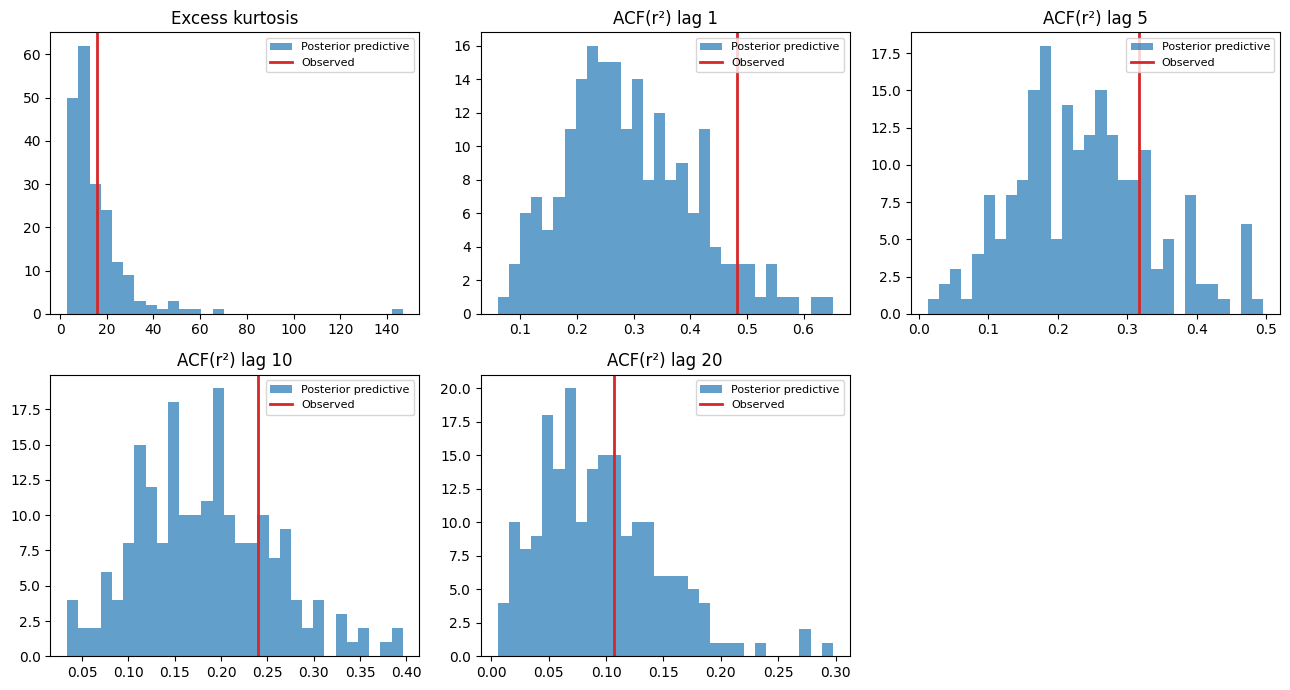

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes = axes.flatten()

stat_names = ["kurtosis", "acf_sq_lag1", "acf_sq_lag5", 
              "acf_sq_lag10", "acf_sq_lag20"]
titles = ["Excess kurtosis", "ACF(r²) lag 1", "ACF(r²) lag 5",
          "ACF(r²) lag 10", "ACF(r²) lag 20"]

for ax, stat, title in zip(axes, stat_names, titles):
    ax.hist(rep_stats[stat], bins=30, alpha=0.7, color="C0",
            label="Posterior predictive")
    ax.axvline(obs_stats[stat], color="C3", lw=2, label="Observed")
    ax.set_title(title)
    ax.legend(fontsize=8)

axes[5].axis("off")  # hide unused subplot
plt.tight_layout()
plt.savefig("../figures/ppc_stylised_facts.png", dpi=150)
plt.show()

Compute Bayesian p-values:

In [5]:
print("\nBayesian p-values (proportion of replicates exceeding observed):")
print("Values near 0.5 = good fit; near 0 or 1 = model under/overshoots")
for stat in stat_names:
    p = (rep_stats[stat] >= obs_stats[stat]).mean()
    print(f"  {stat}: p = {p:.3f}")


Bayesian p-values (proportion of replicates exceeding observed):
Values near 0.5 = good fit; near 0 or 1 = model under/overshoots
  kurtosis: p = 0.335
  acf_sq_lag1: p = 0.065
  acf_sq_lag5: p = 0.200
  acf_sq_lag10: p = 0.215
  acf_sq_lag20: p = 0.355


In [ ]:
pd.DataFrame({"statistic": list(obs_stats.keys()),
              "observed": list(obs_stats.values()),
              "p_value": [(rep_stats[s] >= obs_stats[s]).mean() 
                          for s in obs_stats.keys()]
             }).to_csv("../data_and_results/ppc_pvalues.csv", index=False)